In [28]:
!pip install ultralytics

In [ ]:
import os
os.listdir('/content')

['.config', 'yolov8n.pt', 'drive', 'sample_data']

In [ ]:
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Path to your zip file in Google Drive
zip_path = "/content/drive/MyDrive/AOD_ 4.zip"

# Extract location
extract_path = "/content/dataset"

# Extract the zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


In [ ]:
import os

os.listdir("/content/dataset")

['AOD 4']

In [ ]:
import os

ann_path = "/content/dataset/AOD 4/Annotations"

files = os.listdir(ann_path)

print(files[:5])


['PASCAL VOC Annotation format', 'TF Record Annotation format', 'YOLOv8 OBB format', 'COCO Annotation format', 'YOLOv8 format']


In [ ]:
import os

print(os.listdir("/content/dataset/AOD 4"))

['Images', 'Annotations']


In [ ]:
print(os.listdir("/content/dataset/AOD 4/Annotations"))

['PASCAL VOC Annotation format', 'TF Record Annotation format', 'YOLOv8 OBB format', 'COCO Annotation format', 'YOLOv8 format']


In [ ]:
print(os.listdir("/content/dataset/AOD 4/Annotations/YOLOv8 format"))

['test', 'valid', 'train']


In [ ]:
%%writefile "/content/dataset/AOD 4/Annotations/YOLOv8 format/data.yaml"

train: train/images
val: valid/images
test: test/images

nc: 1
names: ['drone']

Writing /content/dataset/AOD 4/Annotations/YOLOv8 format/data.yaml


In [ ]:
import os

print(os.listdir("/content/dataset/AOD 4/Annotations/YOLOv8 format"))

['data.yaml', 'test', 'valid', 'train']


In [ ]:
import os

print(os.path.exists("/content/dataset/AOD 4/Annotations/YOLOv8 format/data.yaml"))

True


In [ ]:
import os

base = "/content/dataset/AOD 4/Annotations/YOLOv8 format"

print("Train:", os.listdir(base + "/train"))
print("Valid:", os.listdir(base + "/valid"))
print("Test:", os.listdir(base + "/test"))

Train: ['labels']
Valid: ['labels']
Test: ['labels']


In [ ]:
%%writefile "/content/dataset/AOD 4/Annotations/YOLOv8 format/data.yaml"

path: /content/dataset/AOD 4

train: Images/train
val: Images/valid
test: Images/test

nc: 1

names:
  0: drone

Overwriting /content/dataset/AOD 4/Annotations/YOLOv8 format/data.yaml


In [ ]:
import os
import shutil

base = "/content/dataset/AOD 4"

# Create proper YOLO structure
for split in ["train", "valid", "test"]:
    os.makedirs(f"{base}/dataset/images/{split}", exist_ok=True)
    os.makedirs(f"{base}/dataset/labels/{split}", exist_ok=True)

    # Copy images
    image_src = f"{base}/Images/{split}"
    image_dst = f"{base}/dataset/images/{split}"

    for file in os.listdir(image_src):
        shutil.copy(os.path.join(image_src, file), image_dst)

    # Copy labels
    label_src = f"{base}/Annotations/YOLOv8 format/{split}/labels"
    label_dst = f"{base}/dataset/labels/{split}"

    for file in os.listdir(label_src):
        shutil.copy(os.path.join(label_src, file), label_dst)

print("Dataset reorganized correctly!")

Dataset reorganized correctly!


In [ ]:
%%writefile "/content/dataset/AOD 4/dataset/data.yaml"

path: /content/dataset/AOD 4/dataset

train: images/train
val: images/valid
test: images/test

nc: 1

names:
  0: drone

Writing /content/dataset/AOD 4/dataset/data.yaml


In [ ]:
!find "/content/dataset/AOD 4" -name "*.cache" -delete

In [ ]:
import os

base = "/content/dataset/AOD 4/dataset"

print(os.listdir(base))
print(os.listdir(base + "/images"))
print(os.listdir(base + "/labels"))

['data.yaml', 'labels', 'images']
['test', 'valid', 'train']
['test', 'valid', 'train']


In [ ]:
!find "/content/dataset/AOD 4" -name "*.cache" -delete

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/AOD 4/dataset/data.yaml",
    epochs=80,
    imgsz=640
)


Streaming output truncated to the last 5000 lines.
train: /content/dataset/AOD 4/dataset/images/train/yt-iOtLHadUyis-0083_jpg.rf.0e1fdb32ad0d99383bafad8bcb94fc1d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/dataset/AOD 4/dataset/images/train/yt-iOtLHadUyis-0087_jpg.rf.b3193e0b0df08bf353ddda9fdd2b8f99.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/dataset/AOD 4/dataset/images/train/yt-iOtLHadUyis-0088_jpg.rf.0ef5f8f7dcfb4d6fada80f7e563a3500.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/dataset/AOD 4/dataset/images/train/yt-iOtLHadUyis-0090_jpg.rf.3631abaaf969f4a7ccf9286052ecfc2d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/dataset/AOD 4/dataset/images/train/yt-iOtLHadUyis

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fa169ce6f30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fa169ce6f30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [35]:
from ultralytics import YOLO
from IPython.display import display, Image
import os

# Load trained model
model = YOLO("/content/runs/detect/train-8/weights/best.pt")

# Test image folder
test_folder = "/content/dataset/AOD 4/dataset/images/test"

# Get first 10 images
images = sorted(os.listdir(test_folder))[:10]

# Full image paths
image_paths = [os.path.join(test_folder, img) for img in images]

# Run prediction
model.predict(
    source=image_paths,
    save=True,
    conf=0.25
)

print("Detection completed!\n")

# Prediction output folder
predict_folder = "/content/runs/detect/predict"

# Display all predicted images
predicted_images = sorted(os.listdir(predict_folder))[:10]

for img in predicted_images:
    print(f"Displaying: {img}")
    display(Image(filename=os.path.join(predict_folder, img)))

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train-8/weights/best.pt'

In [34]:
import os

print(os.listdir("/content/runs/detect"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect'

In [33]:
import os

for folder in os.listdir("/content/runs/detect"):
    path = f"/content/runs/detect/{folder}/weights"

    if os.path.exists(path):
        print(folder, "->", os.listdir(path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect'

In [32]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os

# Load trained model
model = YOLO("/content/runs/detect/train-8/weights/best.pt")

print("Upload an image to detect drones.")
print("Type STOP to quit.\n")

while True:

    user_input = input("Press ENTER to upload an image or type STOP to quit: ")

    if user_input.upper() == "STOP":
        print("Detection stopped.")
        break

    # Upload image
    uploaded = files.upload()

    # Get uploaded filename
    image_path = list(uploaded.keys())[0]

    # Run prediction
    model.predict(
        source=image_path,
        save=True,
        conf=0.25
    )

    # Find latest predict folder
    predict_folders = sorted(
        [f for f in os.listdir("/content/runs/detect") if f.startswith("predict")]
    )

    latest_predict = predict_folders[-1]

    output_path = f"/content/runs/detect/{latest_predict}/{image_path}"

    print(f"\nDetection Result: {image_path}\n")

    # Display detected image
    display(Image(filename=output_path))

    print("\n-----------------------------------\n")

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train-8/weights/best.pt'

In [ ]:
import shutil

shutil.copy(
    "/content/runs/detect/train-8/weights/best.pt",
    "/content/drive/MyDrive/best.pt"
)

print("Model saved successfully!")


Model saved successfully!


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os

print(os.path.exists("/content/drive/MyDrive/best.pt"))

True


Drone Detection Started!
Type STOP anytime to quit.

Press ENTER to upload an image or type STOP: 


Saving light drone.jpg to light drone.jpg

image 1/1 /content/light drone.jpg: 640x640 1 drone, 421.7ms
Speed: 16.6ms preprocess, 421.7ms inference, 43.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Detection Result:



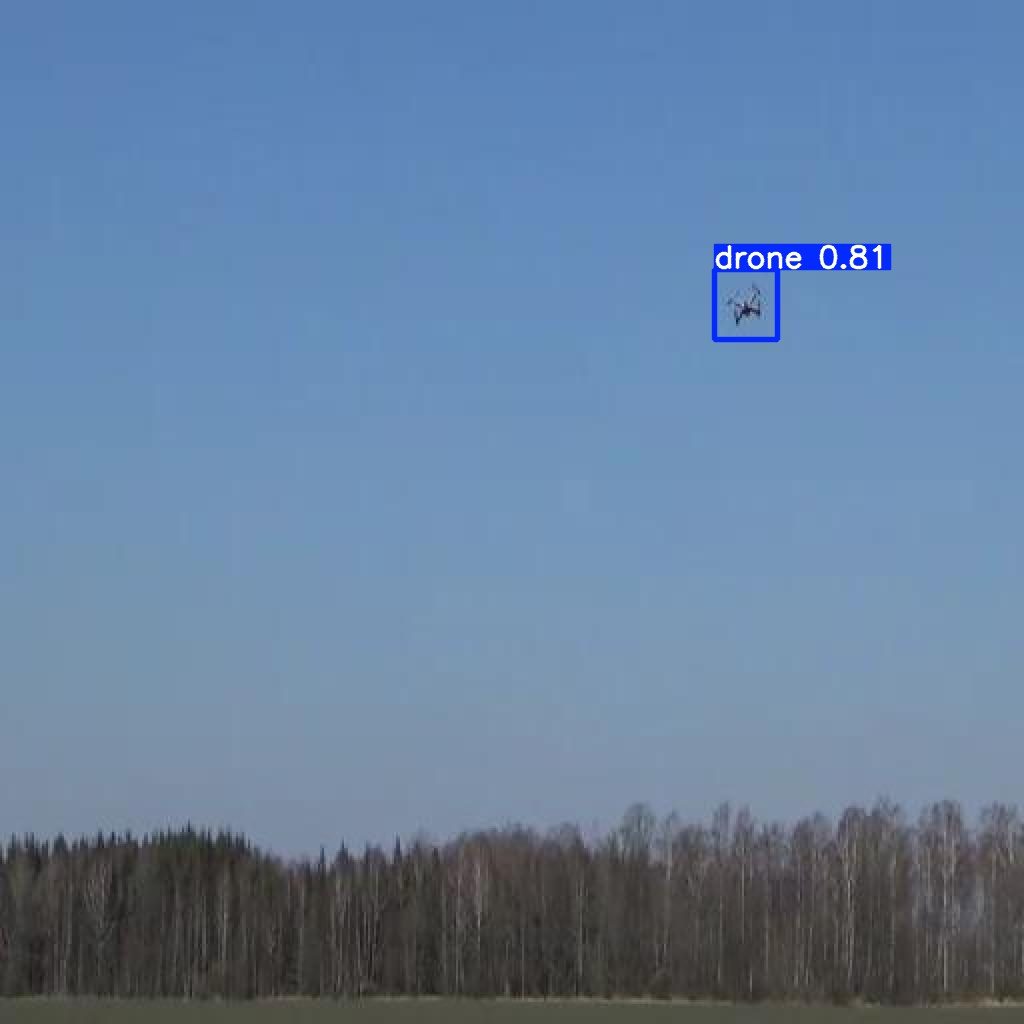


--------------------------------------

Press ENTER to upload an image or type STOP: 


Saving testanm.jpg to testanm.jpg

image 1/1 /content/testanm.jpg: 544x640 (no detections), 498.8ms
Speed: 3.3ms preprocess, 498.8ms inference, 0.8ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict

Detection Result:



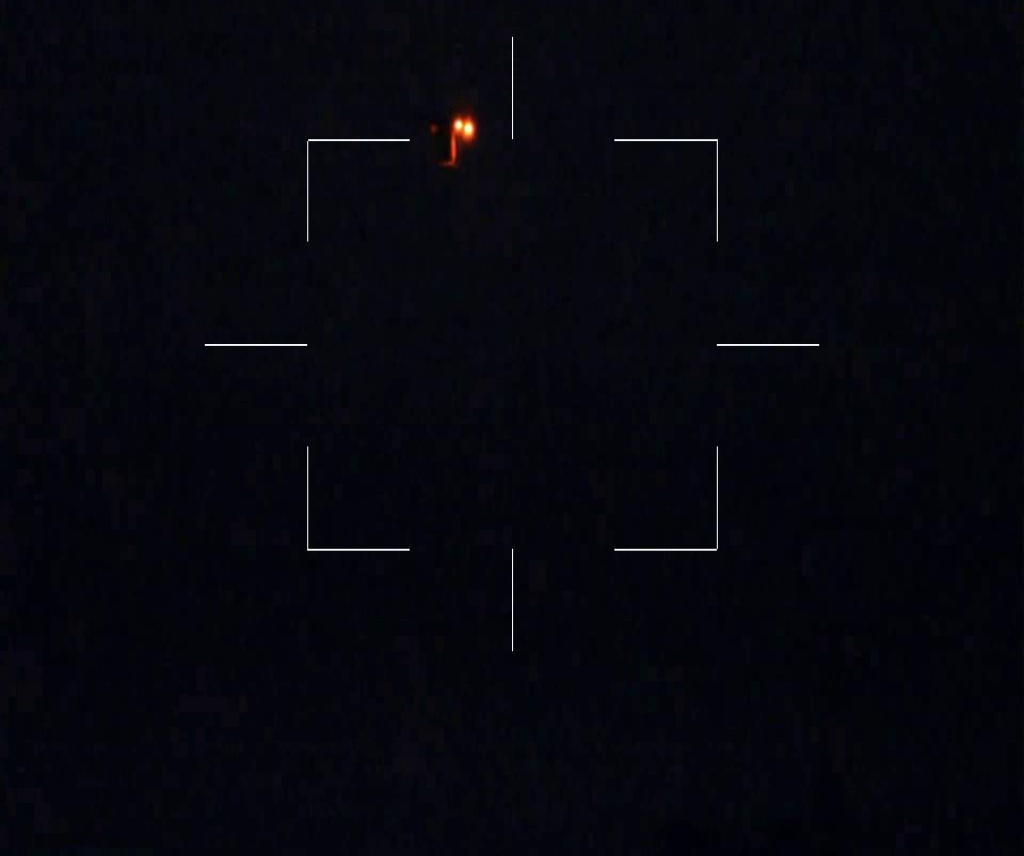


--------------------------------------

Press ENTER to upload an image or type STOP: 


Saving verekili.jpg to verekili.jpg

image 1/1 /content/verekili.jpg: 640x640 (no detections), 213.8ms
Speed: 8.1ms preprocess, 213.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Detection Result:



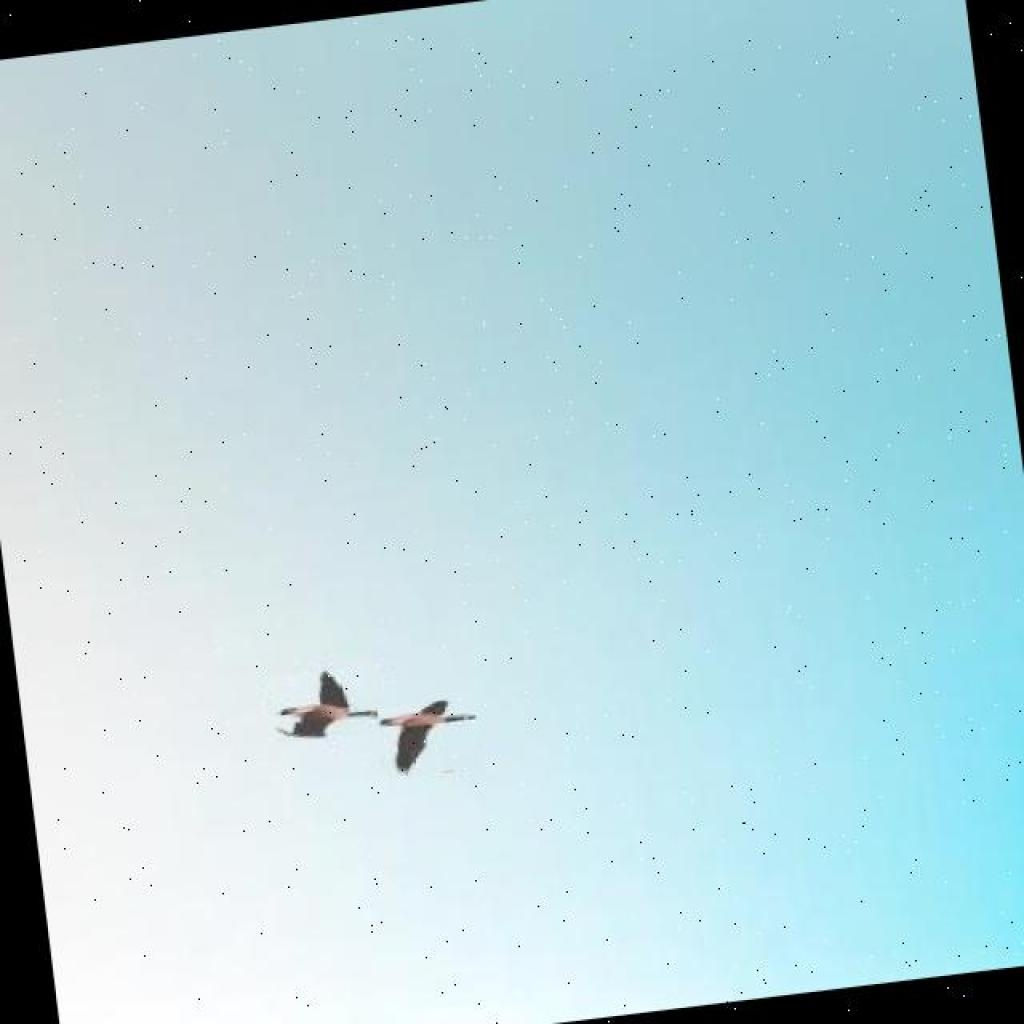


--------------------------------------

Press ENTER to upload an image or type STOP: 


Saving kili.jpg to kili.jpg

image 1/1 /content/kili.jpg: 640x640 (no detections), 343.3ms
Speed: 7.6ms preprocess, 343.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Detection Result:



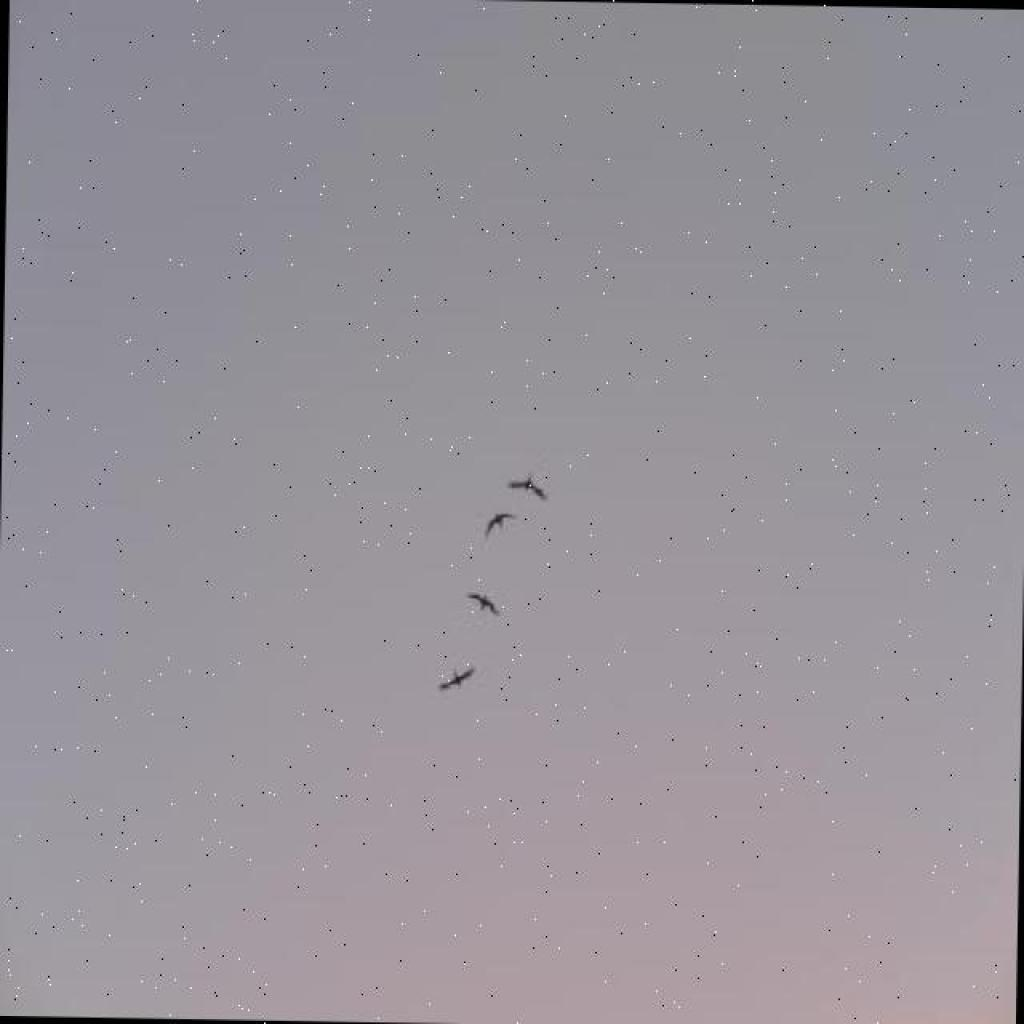


--------------------------------------

Press ENTER to upload an image or type STOP: 


Saving plane.jpg to plane.jpg

image 1/1 /content/plane.jpg: 640x640 1 drone, 216.4ms
Speed: 11.4ms preprocess, 216.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Detection Result:



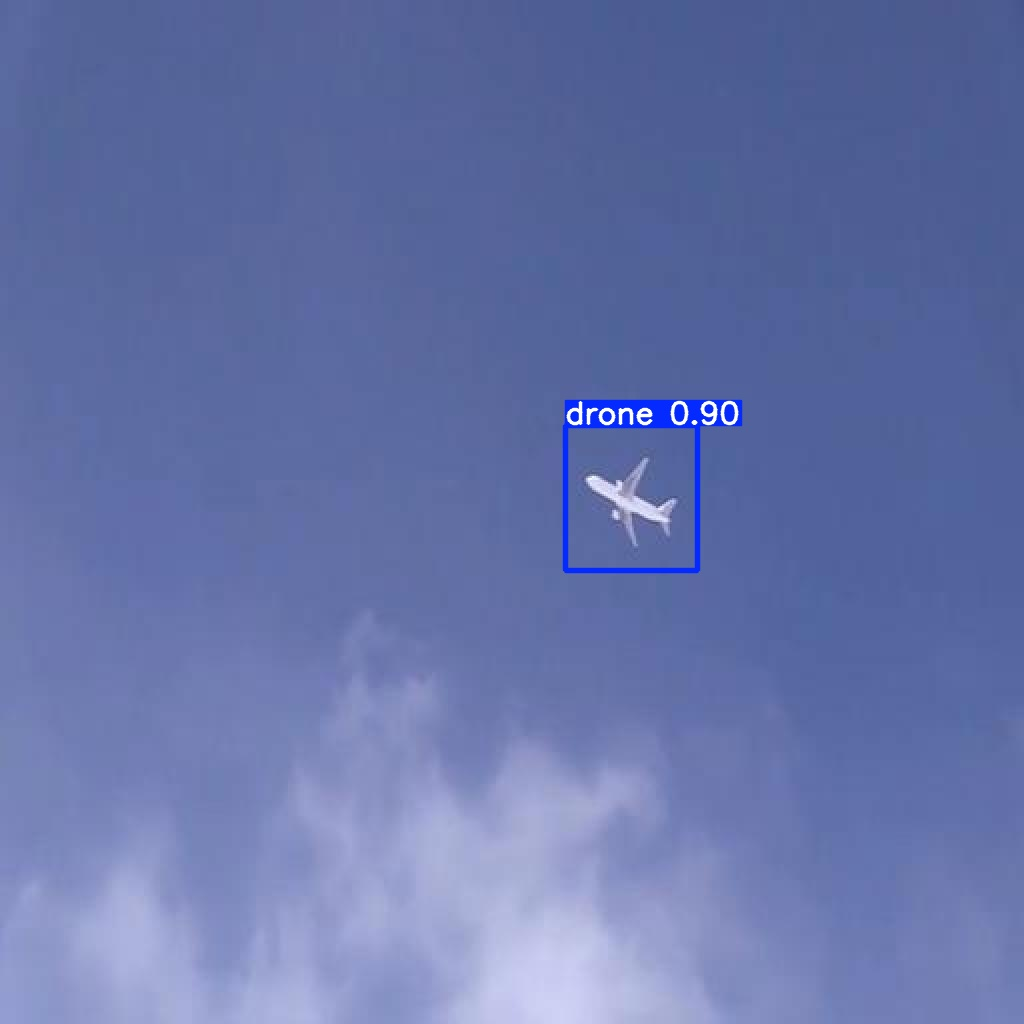


--------------------------------------

Press ENTER to upload an image or type STOP: 


Saving images (4).jpg to images (4).jpg

image 1/1 /content/images (4).jpg: 640x448 1 drone, 274.0ms
Speed: 7.1ms preprocess, 274.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict

Detection Result:



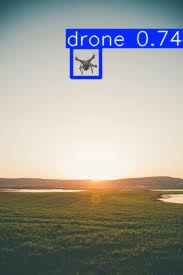


--------------------------------------



In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os

# Load model from Google Drive
model = YOLO("/content/drive/MyDrive/best.pt")

print("Drone Detection Started!")
print("Type STOP anytime to quit.\n")

while True:

    user_input = input("Press ENTER to upload an image or type STOP: ")

    if user_input.upper() == "STOP":
        print("Program stopped.")
        break

    # Upload image
    uploaded = files.upload()

    if len(uploaded) == 0:
        continue

    image_path = list(uploaded.keys())[0]

    # Run detection
    model.predict(
        source=image_path,
        save=True,
        conf=0.25
    )

    # Find newest predict folder
    predict_folders = sorted(
        [f for f in os.listdir("/content/runs/detect") if f.startswith("predict")]
    )

    latest_predict = predict_folders[-1]


    output_path = f"/content/runs/detect/{latest_predict}/{image_path}"

    print("\nDetection Result:\n")

    display(Image(filename=output_path))

    print("\n--------------------------------------\n")

In [30]:
model.predict(
    source="test.jpg",
    save=True
)

FileNotFoundError: test.jpg does not exist